# ESCO Data Profiling & Structure Analysis

## Overview
Initial exploration of the complete ESCO dataset comprising 17 CSV files. This notebook focuses on understanding data structure, quality, and entity relationships.

## Goals
- Load and inventory all 17 ESCO files
- Analyze core entities (occupations, skills, groups)
- Validate data quality and integrity
- Identify hierarchy structures and patterns

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configuration
DATA_RAW = Path('../data/raw')

## 1. Data Inventory & Loading

First, let's inventory all available ESCO files and load them for analysis.

In [16]:
# Define all ESCO files and their purposes
esco_files = {
    # Core entities
    'occupations': 'occupations_en.csv',
    'skills': 'skills_en.csv',
    'skill_groups': 'skillGroups_en.csv',
    'isco_groups': 'ISCOGroups_en.csv',
    
    # Relationships
    'occupation_skills': 'occupationSkillRelations_en.csv',
    'skill_relations': 'skillSkillRelations_en.csv',
    
    # Hierarchies
    'skills_hierarchy': 'skillsHierarchy_en.csv',
    'broader_occ': 'broaderRelationsOccPillar_en.csv',
    'broader_skill': 'broaderRelationsSkillPillar_en.csv',
    
    # Skill collections
    'digital_skills': 'digitalSkillsCollection_en.csv',
    'green_skills': 'greenSkillsCollection_en.csv',
    'language_skills': 'languageSkillsCollection_en.csv',
    'transversal_skills': 'transversalSkillsCollection_en.csv',
    'research_skills': 'researchSkillsCollection_en.csv',
    'digcomp_skills': 'digCompSkillsCollection_en.csv',
    
    # Occupation collections
    'research_occupations': 'researchOccupationsCollection_en.csv',
    
    # Metadata
    'concept_schemes': 'conceptSchemes_en.csv'
}

# Load all files with error handling
dataframes = {}
missing_files = []

for name, filename in esco_files.items():
    filepath = DATA_RAW / filename
    if filepath.exists():
        try:
            dataframes[name] = pd.read_csv(filepath)
            print(f"✅ Loaded {filename} ({len(dataframes[name])} rows)")
        except Exception as e:
            print(f"❌ Failed to load {filename}: {e}")
            missing_files.append(filename)
    else:
        print(f"❌ Missing {filename}")
        missing_files.append(filename)

print(f"\n📊 Loaded {len(dataframes)} out of {len(esco_files)} files")

✅ Loaded occupations_en.csv (3039 rows)
✅ Loaded skills_en.csv (13939 rows)
✅ Loaded skillGroups_en.csv (640 rows)
✅ Loaded ISCOGroups_en.csv (619 rows)
✅ Loaded occupationSkillRelations_en.csv (129004 rows)
✅ Loaded skillSkillRelations_en.csv (5818 rows)
✅ Loaded skillsHierarchy_en.csv (640 rows)
✅ Loaded broaderRelationsOccPillar_en.csv (3652 rows)
✅ Loaded broaderRelationsSkillPillar_en.csv (20822 rows)
✅ Loaded digitalSkillsCollection_en.csv (1284 rows)
✅ Loaded greenSkillsCollection_en.csv (591 rows)
✅ Loaded languageSkillsCollection_en.csv (359 rows)
✅ Loaded transversalSkillsCollection_en.csv (95 rows)
✅ Loaded researchSkillsCollection_en.csv (40 rows)
✅ Loaded digCompSkillsCollection_en.csv (25 rows)
✅ Loaded researchOccupationsCollection_en.csv (122 rows)
✅ Loaded conceptSchemes_en.csv (19 rows)

📊 Loaded 17 out of 17 files


## 2. Core Entity Analysis

Let's examine the main entities: Occupations, Skills, Skill Groups, and ISCO Groups.


📊 COMPACT DATASET OVERVIEW


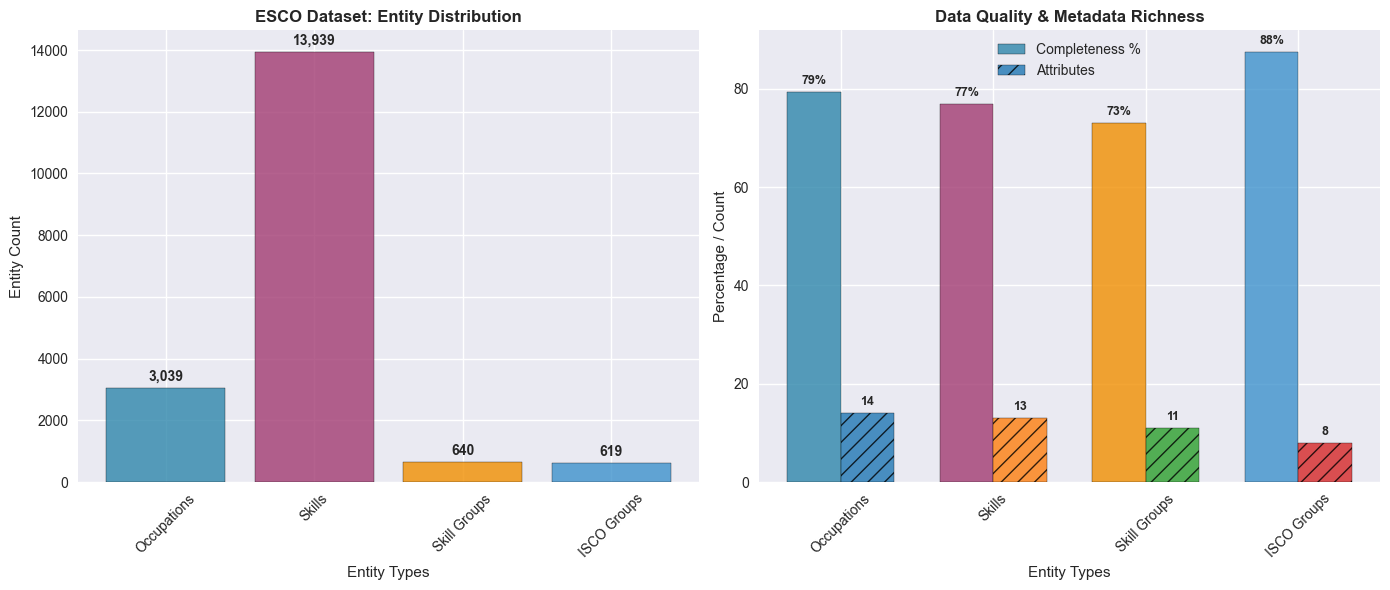


📈 QUICK STATS:
• Total entities: 18,237
• Skills per occupation: 4.6
• Average attributes per entity: 11.5
• Overall data completeness: 79.2%


In [21]:
# Compact Dataset Overview
print("\n📊 COMPACT DATASET OVERVIEW")

# Dynamic data extraction
entities = ['Occupations', 'Skills', 'Skill Groups', 'ISCO Groups']
entity_keys = ['occupations', 'skills', 'skill_groups', 'isco_groups']

counts = [len(dataframes[key]) for key in entity_keys]
column_counts = [len(dataframes[key].columns) for key in entity_keys]

# Calculate actual data completeness
data_completeness = []
for key in entity_keys:
    df = dataframes[key]
    total_cells = df.size
    non_null_cells = total_cells - df.isnull().sum().sum()
    completeness = (non_null_cells / total_cells) * 100 if total_cells > 0 else 0
    data_completeness.append(round(completeness, 1))

# Calculate ratios
occupation_count = counts[0]
other_ratios = [count / occupation_count for count in counts]

colors = ['#2E86AB', '#A23B72', '#F18F01', '#3E92CC']

# Create compact visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: Entity counts comparison
bars_left = ax1.bar(entities, counts, color=colors, alpha=0.8, edgecolor='black')
ax1.set_title('ESCO Dataset: Entity Distribution', fontweight='bold', fontsize=12)
ax1.set_ylabel('Entity Count')
ax1.set_xlabel('Entity Types')
ax1.tick_params(axis='x', rotation=45)

# Add actual values as labels
for i, (bar, count) in enumerate(zip(bars_left, counts)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Right: Data completeness and attributes with different styles
x_pos = np.arange(len(entities))
width = 0.35

# Use different color palette for attributes to distinguish from completeness
attribute_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars_right1 = ax2.bar(x_pos - width/2, data_completeness, width, 
                     color=colors, alpha=0.8, label='Completeness %', edgecolor='black')
bars_right2 = ax2.bar(x_pos + width/2, column_counts, width, 
                     color=attribute_colors, alpha=0.8, label='Attributes', 
                     edgecolor='black', hatch='//')

ax2.set_title('Data Quality & Metadata Richness', fontweight='bold', fontsize=12)
ax2.set_ylabel('Percentage / Count')
ax2.set_xlabel('Entity Types')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(entities)
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

# Add value labels for right chart
for bars in [bars_right1, bars_right2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.0f}{"%" if bars == bars_right1 else ""}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Quick stats
total_entities = sum(counts)
skills_per_occupation = other_ratios[1]
avg_attributes = sum(column_counts) / len(column_counts)
overall_completeness = sum(data_completeness) / len(data_completeness)

print(f"\n📈 QUICK STATS:")
print(f"• Total entities: {total_entities:,}")
print(f"• Skills per occupation: {skills_per_occupation:.1f}")
print(f"• Average attributes per entity: {avg_attributes:.1f}")
print(f"• Overall data completeness: {overall_completeness:.1f}%")

## 3. Data Quality Assessment

Check for missing values, URI uniqueness, and data consistency across files.

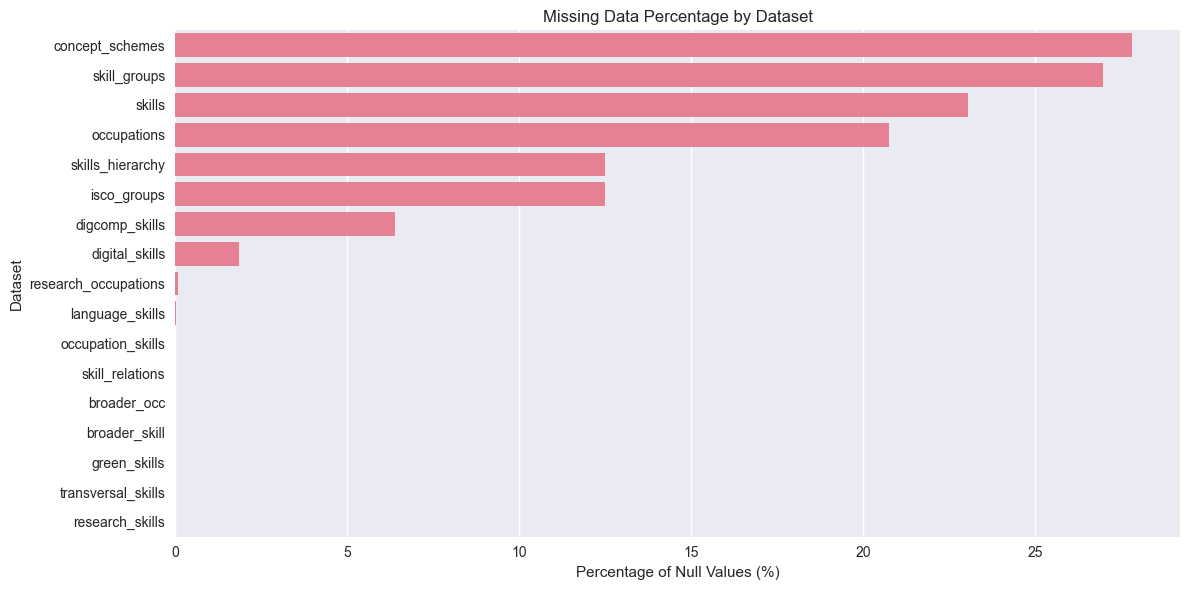

🔍 Top datasets with missing values:


,Dataset,Total_Rows,Total_Columns,Null_Cells,Null_Percent
16,concept_schemes,19,7,37,27.82
2,skill_groups,640,11,1899,26.97
1,skills,13939,13,41785,23.06
0,occupations,3039,14,8822,20.74
6,skills_hierarchy,640,14,1121,12.51
3,isco_groups,619,8,619,12.50
14,digcomp_skills,25,10,16,6.40
9,digital_skills,1284,10,237,1.85


In [22]:
# Check for missing values across all datasets
null_analysis = []
for name, df in dataframes.items():
    total_cells = df.size
    null_cells = df.isnull().sum().sum()
    null_percent = (null_cells / total_cells) * 100 if total_cells > 0 else 0
    
    null_analysis.append({
        'Dataset': name,
        'Total_Rows': len(df),
        'Total_Columns': len(df.columns),
        'Null_Cells': null_cells,
        'Null_Percent': round(null_percent, 2)
    })

null_df = pd.DataFrame(null_analysis).sort_values('Null_Percent', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=null_df, x='Null_Percent', y='Dataset')
plt.title('Missing Data Percentage by Dataset')
plt.xlabel('Percentage of Null Values (%)')
plt.tight_layout()
plt.show()

print("🔍 Top datasets with missing values:")
display(null_df.head(8))

## 4. URI Uniqueness Validation

Validate that core entities have unique URIs across the dataset.


🔗 URI ANALYSIS: Quick Assessment


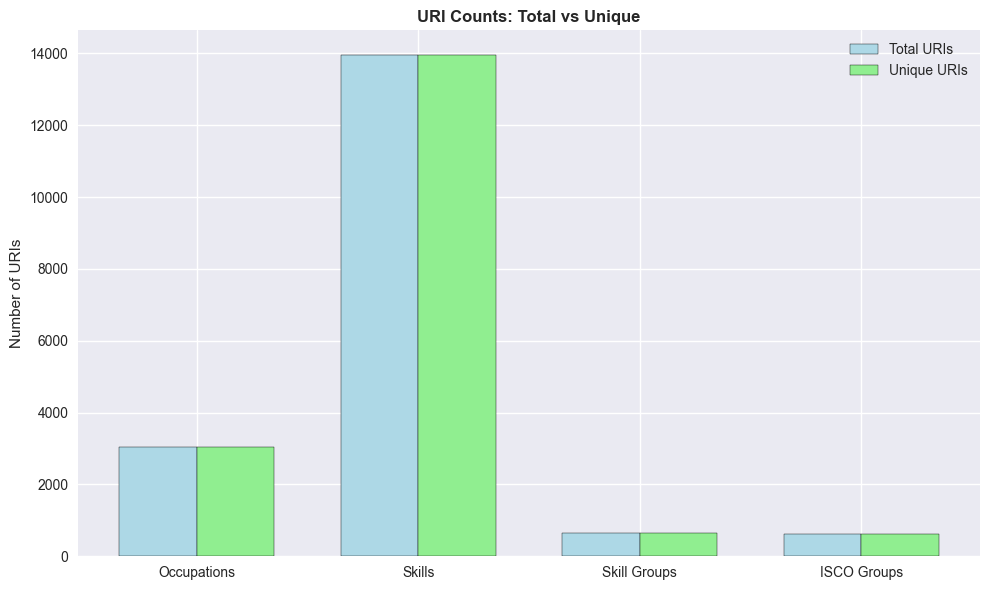

In [31]:
# URI Analysis: Quick Assessment
print("\n🔗 URI ANALYSIS: Quick Assessment")

uri_stats = []
for df, name in [(occupations, 'Occupations'), 
                 (skills, 'Skills'),
                 (skill_groups, 'Skill Groups'),
                 (isco_groups, 'ISCO Groups')]:
    if df is not None and 'conceptUri' in df.columns:
        uris = df['conceptUri']
        uri_stats.append({
            'entity': name,
            'total': len(uris),
            'unique': uris.nunique()
        })

fig, ax = plt.subplots(figsize=(10, 6))

entities = [s['entity'] for s in uri_stats]
totals = [s['total'] for s in uri_stats]
uniques = [s['unique'] for s in uri_stats]

x = np.arange(len(entities))
width = 0.35

ax.bar(x - width/2, totals, width, label='Total URIs', color='lightblue', edgecolor='black')
ax.bar(x + width/2, uniques, width, label='Unique URIs', color='lightgreen', edgecolor='black')

ax.set_title('URI Counts: Total vs Unique', fontweight='bold')
ax.set_ylabel('Number of URIs')
ax.set_xticks(x)
ax.set_xticklabels(entities)
ax.legend()

plt.tight_layout()
plt.show()

## 5. Skill Type & Collection Analysis

Analyze the distribution of skill types and their presence across different collections.

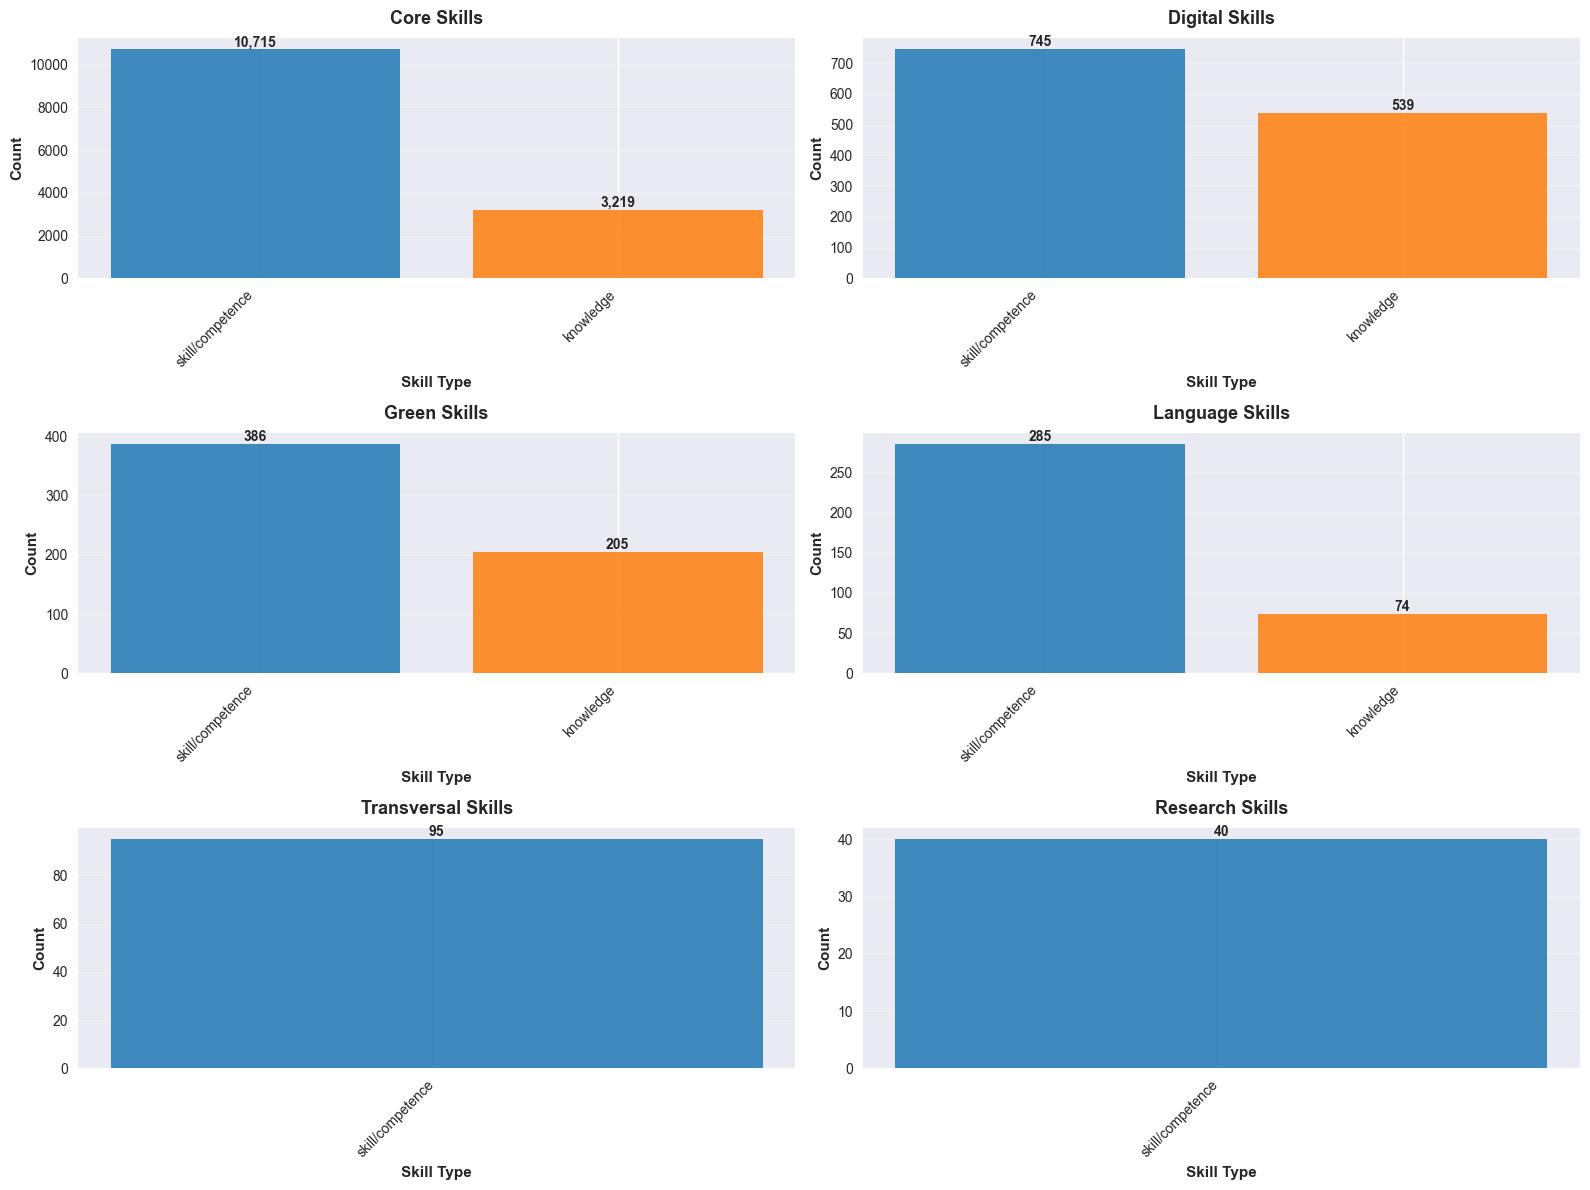

In [50]:
# Analyze skill types across different datasets
skill_analysis = {}

# Core skills dataset
if skills is not None and 'skillType' in skills.columns:
    skill_analysis['Core Skills'] = skills['skillType'].value_counts()

# Collection skill types
collections = {
    'digital_skills': 'Digital Skills',
    'green_skills': 'Green Skills', 
    'language_skills': 'Language Skills',
    'transversal_skills': 'Transversal Skills',
    'research_skills': 'Research Skills'
}

for col_var, col_name in collections.items():
    df = globals().get(col_var)
    if df is not None and 'skillType' in df.columns:
        skill_analysis[col_name] = df['skillType'].value_counts()

# Plot skill type distribution
if skill_analysis:
    n_plots = len(skill_analysis)
    n_cols = 2
    n_rows = 3
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
    axes = axes.ravel()
    
    # Better color palette - vibrant and distinct
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    for i, (dataset, counts) in enumerate(skill_analysis.items()):
        bars = axes[i].bar(range(len(counts)), counts.values, color=colors[:len(counts)], alpha=0.85)
        
        axes[i].set_title(dataset, fontsize=13, fontweight='bold', pad=10)
        axes[i].set_xlabel('Skill Type', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Count', fontsize=11, fontweight='bold')
        axes[i].set_xticks(range(len(counts)))
        axes[i].set_xticklabels(counts.index, rotation=45, ha='right', fontsize=10)
        
        # Add value labels on bars
        for bar, count in zip(bars, counts.values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                       f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        axes[i].grid(True, alpha=0.3, axis='y')
        axes[i].set_axisbelow(True)
    
    # Hide empty subplots
    for j in range(len(skill_analysis), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

else:
    print("No skill type data available")

## 6. Relationship Data Overview

Examine the relationship files that will form the graph connections.

🤝 Relationship Statistics:


,Relationship_Type,Total_Relationships,Unique_Occupations,Unique_Skills,Relation_Types,Unique_Source_Skills,Unique_Target_Skills
0,Occupation-Skill,129004,3039.0,13492.0,2,NaN,NaN
1,Skill-Skill,5818,NaN,NaN,2,3759.0,1953.0


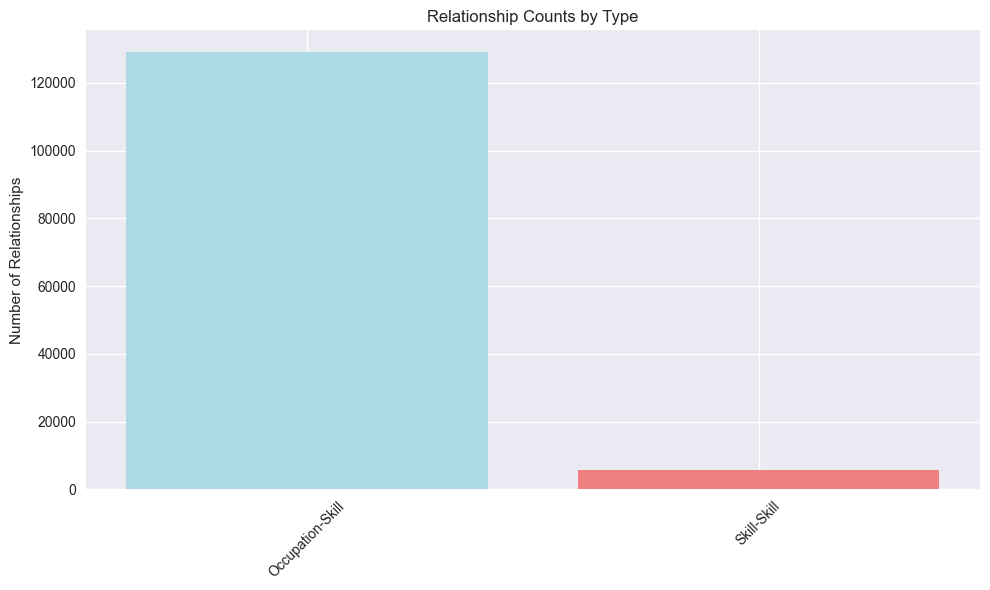

In [51]:
# Analyze relationship datasets
relationship_stats = []

if 'occupation_skills' in dataframes:
    rel_df = dataframes['occupation_skills']
    relationship_stats.append({
        'Relationship_Type': 'Occupation-Skill',
        'Total_Relationships': len(rel_df),
        'Unique_Occupations': rel_df['occupationUri'].nunique(),
        'Unique_Skills': rel_df['skillUri'].nunique(),
        'Relation_Types': rel_df['relationType'].nunique() if 'relationType' in rel_df.columns else 1
    })

if 'skill_relations' in dataframes:
    rel_df = dataframes['skill_relations']
    relationship_stats.append({
        'Relationship_Type': 'Skill-Skill', 
        'Total_Relationships': len(rel_df),
        'Unique_Source_Skills': rel_df['originalSkillUri'].nunique(),
        'Unique_Target_Skills': rel_df['relatedSkillUri'].nunique(),
        'Relation_Types': rel_df['relationType'].nunique() if 'relationType' in rel_df.columns else 1
    })

if relationship_stats:
    rel_df = pd.DataFrame(relationship_stats)
    print("🤝 Relationship Statistics:")
    display(rel_df)
    
    # Visualize relationship volumes
    plt.figure(figsize=(10, 6))
    plt.bar(rel_df['Relationship_Type'], rel_df['Total_Relationships'], color=['lightblue', 'lightcoral'])
    plt.title('Relationship Counts by Type')
    plt.ylabel('Number of Relationships')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 7. Hierarchy Structure Analysis

Analyze the multi-level hierarchy structures in skills and occupations.


🌳 HIERARCHY STRUCTURE ANALYSIS


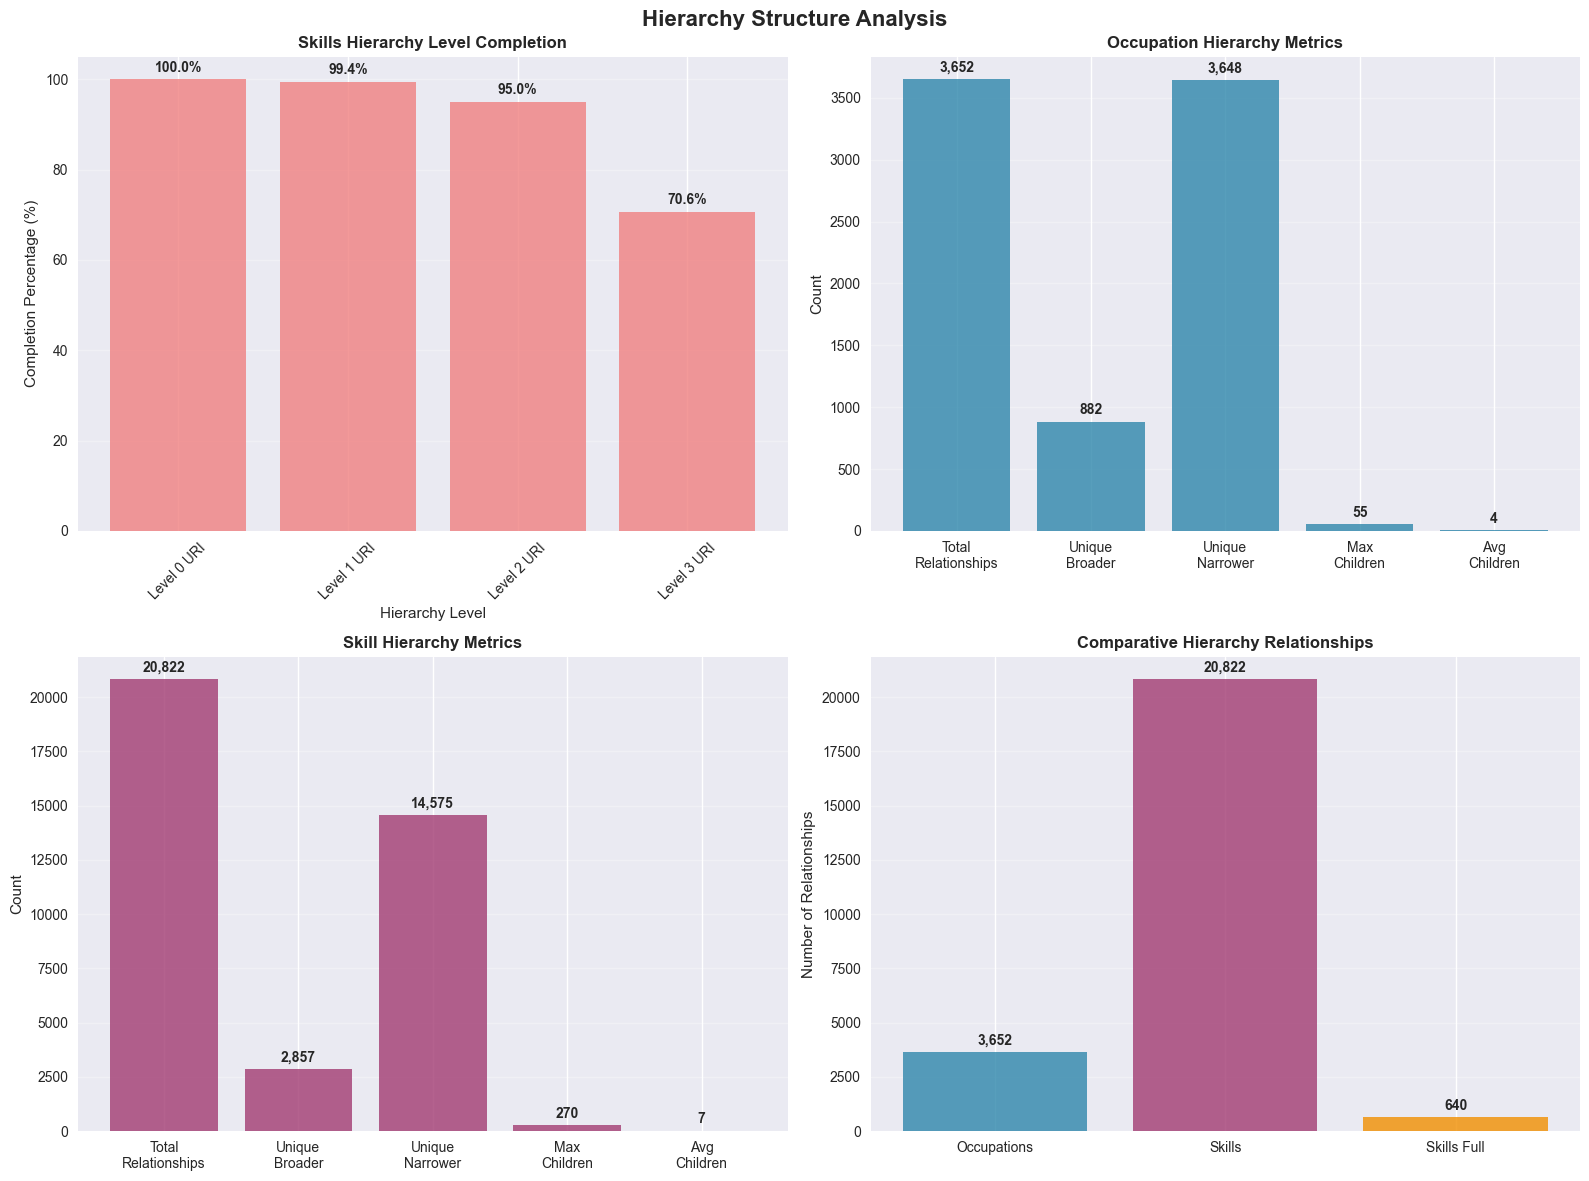

In [60]:
# Hierarchy Structure Analysis - Visual Edition
print("\n🌳 HIERARCHY STRUCTURE ANALYSIS")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hierarchy Structure Analysis', fontsize=16, fontweight='bold')

# Plot 1: Skills Hierarchy Level Completion
if skills_hierarchy_full is not None:
    skill_level_columns = ['Level 0 URI', 'Level 1 URI', 'Level 2 URI', 'Level 3 URI']
    skill_level_stats = {}
    
    for level_col in skill_level_columns:
        if level_col in skills_hierarchy_full.columns:
            non_null_count = skills_hierarchy_full[level_col].notna().sum()
            skill_level_stats[level_col] = round((non_null_count / len(skills_hierarchy_full)) * 100, 1)
    
    if skill_level_stats:
        levels = list(skill_level_stats.keys())
        completion = list(skill_level_stats.values())
        
        bars = axes[0,0].bar(levels, completion, color='lightcoral', alpha=0.8)
        axes[0,0].set_title('Skills Hierarchy Level Completion', fontweight='bold')
        axes[0,0].set_ylabel('Completion Percentage (%)')
        axes[0,0].set_xlabel('Hierarchy Level')
        axes[0,0].tick_params(axis='x', rotation=45)
        
        for bar, value in zip(bars, completion):
            axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                          f'{value}%', ha='center', va='bottom', fontweight='bold')
        axes[0,0].grid(True, alpha=0.3, axis='y')

# Plot 2: Occupation Hierarchy Metrics
if occupation_hierarchy is not None:
    occ_metrics = [
        len(occupation_hierarchy),
        occupation_hierarchy['broaderUri'].nunique(),
        occupation_hierarchy['conceptUri'].nunique(),
        occupation_hierarchy.groupby('broaderUri').size().max(),
        occupation_hierarchy.groupby('broaderUri').size().mean()
    ]
    
    occ_labels = ['Total\nRelationships', 'Unique\nBroader', 'Unique\nNarrower', 'Max\nChildren', 'Avg\nChildren']
    
    bars = axes[0,1].bar(occ_labels, occ_metrics, color='#2E86AB', alpha=0.8)
    axes[0,1].set_title('Occupation Hierarchy Metrics', fontweight='bold')
    axes[0,1].set_ylabel('Count')
    
    for bar, value in zip(bars, occ_metrics):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(occ_metrics)*0.01, 
                      f'{value:,.0f}', ha='center', va='bottom', fontweight='bold')
    axes[0,1].grid(True, alpha=0.3, axis='y')

# Plot 3: Skill Hierarchy Metrics
if skill_hierarchy is not None:
    skill_metrics = [
        len(skill_hierarchy),
        skill_hierarchy['broaderUri'].nunique(),
        skill_hierarchy['conceptUri'].nunique(),
        skill_hierarchy.groupby('broaderUri').size().max(),
        skill_hierarchy.groupby('broaderUri').size().mean()
    ]
    
    skill_labels = ['Total\nRelationships', 'Unique\nBroader', 'Unique\nNarrower', 'Max\nChildren', 'Avg\nChildren']
    
    bars = axes[1,0].bar(skill_labels, skill_metrics, color='#A23B72', alpha=0.8)
    axes[1,0].set_title('Skill Hierarchy Metrics', fontweight='bold')
    axes[1,0].set_ylabel('Count')
    
    for bar, value in zip(bars, skill_metrics):
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(skill_metrics)*0.01, 
                      f'{value:,.0f}', ha='center', va='bottom', fontweight='bold')
    axes[1,0].grid(True, alpha=0.3, axis='y')

# Plot 4: Comparative Hierarchy Relationships
hierarchy_data = []
labels = []
if occupation_hierarchy is not None:
    hierarchy_data.append(len(occupation_hierarchy))
    labels.append('Occupations')
if skill_hierarchy is not None:
    hierarchy_data.append(len(skill_hierarchy))
    labels.append('Skills')
if skills_hierarchy_full is not None:
    hierarchy_data.append(len(skills_hierarchy_full))
    labels.append('Skills Full')

if hierarchy_data:
    bars = axes[1,1].bar(labels, hierarchy_data, color=['#2E86AB', '#A23B72', '#F18F01'], alpha=0.8)
    axes[1,1].set_title('Comparative Hierarchy Relationships', fontweight='bold')
    axes[1,1].set_ylabel('Number of Relationships')
    
    for bar, count in zip(bars, hierarchy_data):
        axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(hierarchy_data)*0.01, 
                      f'{count:,}', ha='center', va='bottom', fontweight='bold')
    axes[1,1].grid(True, alpha=0.3, axis='y')

# Hide any empty subplots
for i in range(2):
    for j in range(2):
        if not axes[i,j].has_data():
            axes[i,j].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Data Quality Summary

Final assessment of data quality and readiness for graph construction.

📋 COMPREHENSIVE DATA QUALITY SUMMARY
Total datasets analyzed: 17
Total rows across all datasets: 180,708
Average null percentage: 7.8%
Datasets with >10% null values: 6


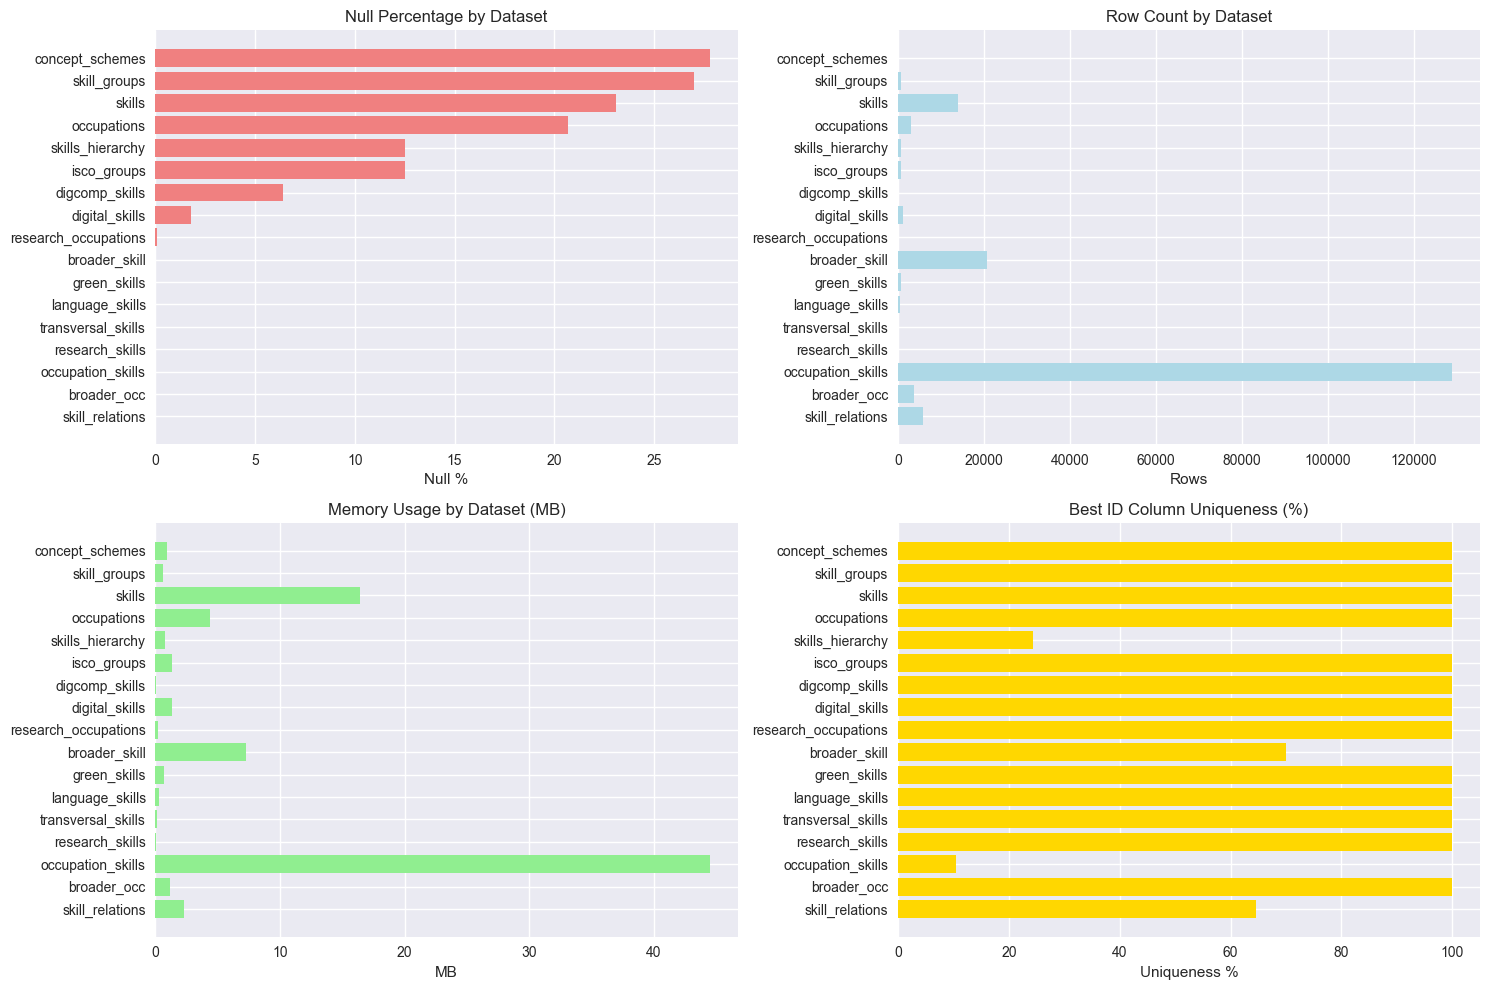


✅ PROFILING COMPLETE
Next steps: Proceed to 02_relationships.ipynb for graph topology analysis


In [62]:
# Comprehensive data quality summary
quality_summary = []

for name, df in dataframes.items():
    # Basic stats
    total_cells = df.size
    null_cells = df.isnull().sum().sum()
    null_percent = (null_cells / total_cells) * 100 if total_cells > 0 else 0
    
    # Check for potential ID columns
    id_candidates = [col for col in df.columns if any(x in col.lower() for x in ['uri', 'id', 'code'])]
    uniqueness_stats = {}
    
    for col in id_candidates[:3]:  # Check first 3 candidate columns
        if col in df.columns:
            uniqueness_stats[col] = round(df[col].nunique() / len(df) * 100, 1)
    
    quality_summary.append({
        'Dataset': name,
        'Rows': len(df),
        'Columns': len(df.columns),
        'Null_Percent': round(null_percent, 1),
        'Memory_MB': round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        'ID_Uniqueness': max(uniqueness_stats.values()) if uniqueness_stats else 0
    })

quality_df = pd.DataFrame(quality_summary).sort_values('Null_Percent')

print("📋 COMPREHENSIVE DATA QUALITY SUMMARY")
print(f"Total datasets analyzed: {len(quality_df)}")
print(f"Total rows across all datasets: {quality_df['Rows'].sum():,}")
print(f"Average null percentage: {quality_df['Null_Percent'].mean():.1f}%")
print(f"Datasets with >10% null values: {len(quality_df[quality_df['Null_Percent'] > 10])}")

# Display quality metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Null percentage
axes[0,0].barh(quality_df['Dataset'], quality_df['Null_Percent'], color='lightcoral')
axes[0,0].set_title('Null Percentage by Dataset')
axes[0,0].set_xlabel('Null %')

# Row counts
axes[0,1].barh(quality_df['Dataset'], quality_df['Rows'], color='lightblue')
axes[0,1].set_title('Row Count by Dataset')
axes[0,1].set_xlabel('Rows')

# Memory usage
axes[1,0].barh(quality_df['Dataset'], quality_df['Memory_MB'], color='lightgreen')
axes[1,0].set_title('Memory Usage by Dataset (MB)')
axes[1,0].set_xlabel('MB')

# ID uniqueness
axes[1,1].barh(quality_df['Dataset'], quality_df['ID_Uniqueness'], color='gold')
axes[1,1].set_title('Best ID Column Uniqueness (%)')
axes[1,1].set_xlabel('Uniqueness %')

plt.tight_layout()
plt.show()

print("\n✅ PROFILING COMPLETE")
print("Next steps: Proceed to 02_relationships.ipynb for graph topology analysis")